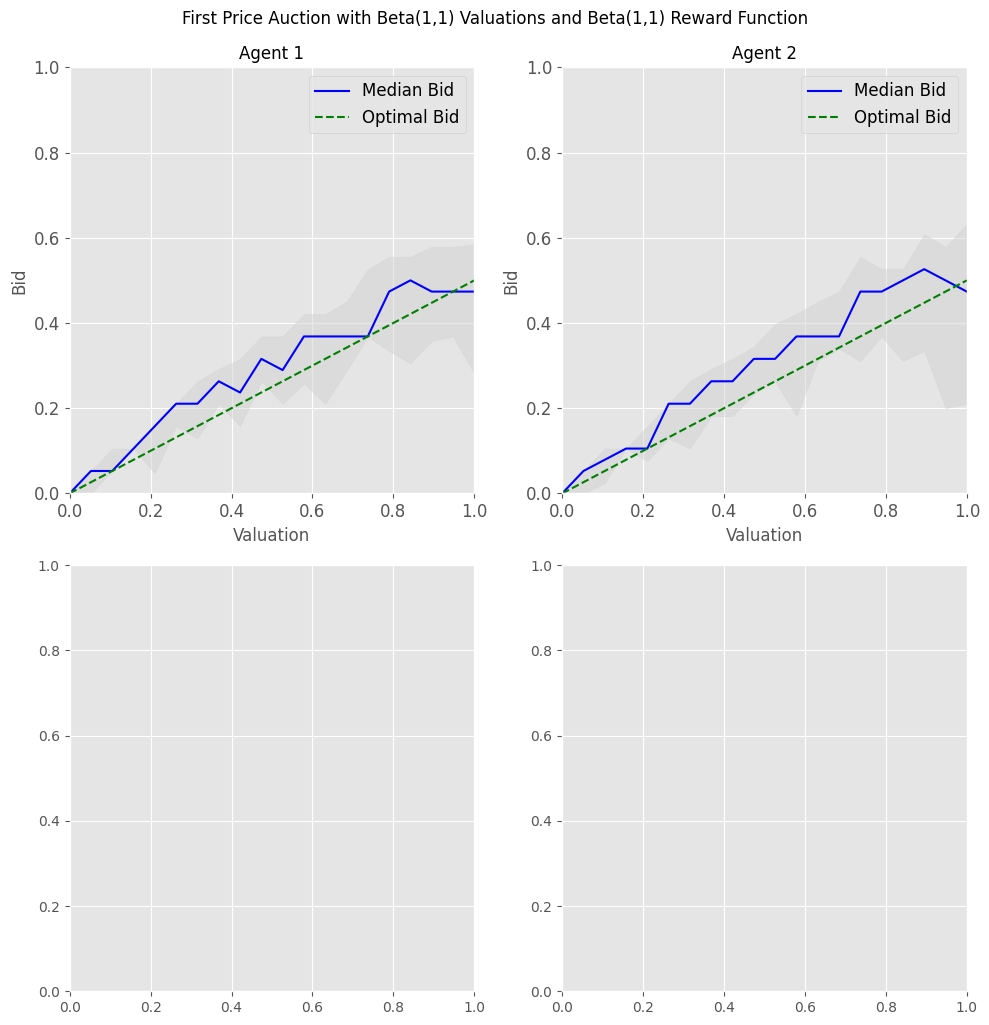

In [3]:
import numpy as np
np.random.seed(33454)
import matplotlib.pyplot as plt
from scipy.stats import beta
plt.style.use('ggplot')

class QLearningAgent:
    def __init__(self, action_min=0, action_max=1,
                 granularity=20, epsilon=0.1, alpha=0.1, min_val=0, max_val=1,
                 epsilon_decay=None, alpha_value=1, beta_value=1, alpha_reward=1, beta_reward=1):
        self.alpha_value = alpha_value
        self.beta_value = beta_value
        self.valuation_distribution = lambda: np.random.beta(self.alpha_value, self.beta_value)
        self.actions = np.linspace(action_min, action_max, granularity)
        self.epsilon = epsilon
        self.epsilon_initial = epsilon  # Store the initial value for epsilon decay purposes
        self.epsilon_decay = epsilon_decay
        self.alpha = alpha
        self.min_val = min_val
        self.max_val = max_val
        self.granularity = granularity
        self.q_values = np.zeros((granularity, len(self.actions)))
        self.action_counts = np.zeros((granularity, len(self.actions)))
        self.reward_history = []
        self.valuation = self.valuation_distribution()
        self.state = self.get_state(self.valuation)
        # Parameters for the Beta reward function
        self.alpha_reward = alpha_reward
        self.beta_reward = beta_reward

    def get_state(self, valuation):
        bin_centers = np.linspace(self.min_val, self.max_val, self.granularity)
        return np.argmin(np.abs(bin_centers - valuation))
    
    def refresh_valuation(self):
        self.valuation = self.valuation_distribution()
        self.state = self.get_state(self.valuation)
    
    def choose_action(self):
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.actions)
        else:
            return self.actions[np.argmax(self.q_values[self.state])]
    
    def update_q_values(self, chosen_action, reward):
        action_index = np.where(self.actions == chosen_action)[0][0]
        self.action_counts[self.state, action_index] += 1
        self.q_values[self.state, action_index] += self.alpha * (reward - self.q_values[self.state, action_index])
    
    def feedback(self, payoff, action):
        # Compute the reward based on the payoff using Beta CDF
        payoff = np.clip(payoff, 0, 1)  # Ensure payoff is within [0, 1]
        reward = beta.cdf(payoff, self.alpha_reward, self.beta_reward)
        self.reward_history.append(reward)
        self.update_q_values(action, reward)
        if self.epsilon_decay:
            # Apply epsilon decay
            self.epsilon = max(0.05, self.epsilon_initial * self.epsilon_decay)

class SingleSidedAuction:
    def __init__(self, agents, price_floor=0, price_ceiling=1, payment_rule=None):
        self.agents = agents
        self.price_floor = price_floor
        self.price_ceiling = price_ceiling
        self.payment_rule = payment_rule
        self.profit_history = []
    
    def run_auction(self):
        for agent in self.agents:
            agent.refresh_valuation()
        bids = [max(self.price_floor, min(agent.choose_action(), self.price_ceiling)) for agent in self.agents]
        winner_index, payment = self.payment_rule(bids)
        for idx, agent in enumerate(self.agents):
            if idx == winner_index:
                payoff = agent.valuation - payment
            else:
                payoff = 0
            agent.feedback(payoff, bids[idx])
        self.profit_history.append(payment)
        return {"winner": winner_index, "payment": payment, "bids": bids}

def run_single_simulation(agents, game, num_rounds=10000):
    for _ in range(num_rounds):
        game.run_auction()
    return [agent.q_values for agent in agents]

def run_monte_carlo_simulation(agents, auction, num_simulations=10, num_rounds=10000):
    all_bids_for_valuations = [[] for _ in range(len(agents))]
    for sim in range(num_simulations):
        run_single_simulation(agents, auction, num_rounds=num_rounds)
        for i, agent in enumerate(agents):
            avg_bids_for_valuation = [agent.actions[np.argmax(agent.q_values[state])] for state in range(agent.granularity)]
            all_bids_for_valuations[i].append(avg_bids_for_valuation)

    percentiles = {}
    for i in range(len(agents)):
        avg_bids_for_agent = np.array(all_bids_for_valuations[i])
        percentiles[i] = {
            "5th": np.percentile(avg_bids_for_agent, 5, axis=0),
            "median": np.median(avg_bids_for_agent, axis=0),
            "95th": np.percentile(avg_bids_for_agent, 95, axis=0),
        }
    return percentiles

def plot_monte_carlo_results(agents, percentiles, optimal_bid_rule=None, figsize=(10, 10), grid_dims=(2, 2), xlim=(0,1), ylim=(0,1), title=None, fontsize=12):
    fig, axes = plt.subplots(grid_dims[0], grid_dims[1], figsize=figsize)
    axes = axes.flatten()
    valuations = np.linspace(0, 1, agents[0].granularity)
    
    for i, agent in enumerate(agents):
        ax = axes[i]
        ax.fill_between(valuations, percentiles[i]["5th"], percentiles[i]["95th"], color='lightgray', alpha=0.5)
        ax.plot(valuations, percentiles[i]["median"], label='Median Bid', color='blue')
        if optimal_bid_rule:
            optimal_bids = optimal_bid_rule(valuations)
            ax.plot(valuations, optimal_bids, label='Optimal Bid', color='green', linestyle='--')
        if xlim: ax.set_xlim(xlim)
        if ylim: ax.set_ylim(ylim)
        ax.set_xlabel('Valuation', fontsize=fontsize)
        ax.set_ylabel('Bid', fontsize=fontsize)
        ax.set_title(f'Agent {i+1}', fontsize=fontsize)
        ax.legend(fontsize=fontsize)
        ax.tick_params(axis='both', which='major', labelsize=fontsize)
    
    plt.tight_layout()
    if title: plt.suptitle(title, y=1.02, fontsize=fontsize)
    plt.show()

def first_price_rule(bids):
    highest_bid = np.max(bids)
    potential_winners = np.where(bids == highest_bid)[0]
    winner = np.random.choice(potential_winners) if len(potential_winners) > 1 else potential_winners[0]
    payment = bids[winner]
    return winner, payment

def optimal_bidding_rule(valuations, num_agents=2):
    return (num_agents - 1) / num_agents * valuations

# Create agents with Beta(1,1) valuation distribution and Beta(1,1) reward function
agents = [QLearningAgent(alpha_value=1, beta_value=1, alpha_reward=1, beta_reward=1) for _ in range(2)]
auction = SingleSidedAuction(agents, payment_rule=first_price_rule)
percentiles = run_monte_carlo_simulation(agents, auction, num_simulations=10, num_rounds=10000)
plot_monte_carlo_results(agents, percentiles, optimal_bid_rule=optimal_bidding_rule, title='First Price Auction with Beta(1,1) Valuations and Beta(1,1) Reward Function')

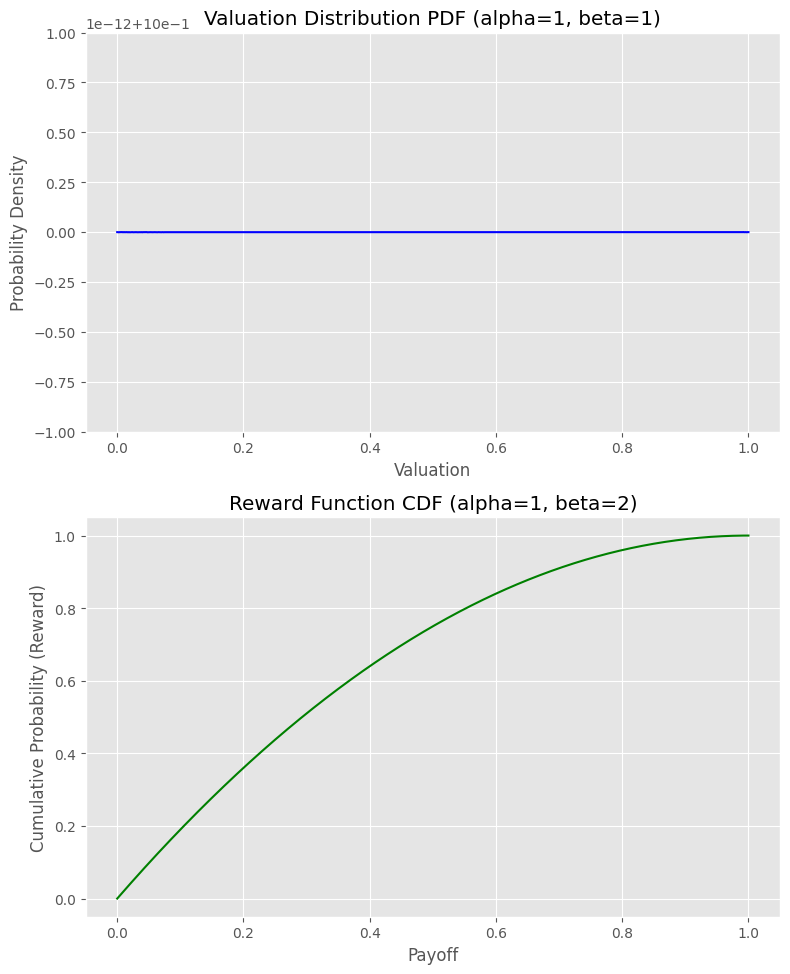

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
plt.style.use('ggplot')

def plot_valuation_and_reward_distributions(alpha_value, beta_value, alpha_reward, beta_reward):
    x = np.linspace(0, 1, 1000)
    
    # Valuation Distribution PDF
    valuation_pdf = beta.pdf(x, alpha_value, beta_value)
    
    # Reward Function CDF
    reward_cdf = beta.cdf(x, alpha_reward, beta_reward)
    
    fig, axs = plt.subplots(2, 1, figsize=(8, 10))
    
    # Plot Valuation Distribution PDF
    axs[0].plot(x, valuation_pdf, color='blue')
    axs[0].set_title(f'Valuation Distribution PDF (alpha={alpha_value}, beta={beta_value})')
    axs[0].set_xlabel('Valuation')
    axs[0].set_ylabel('Probability Density')
    axs[0].grid(True)
    
    # Plot Reward Function CDF
    axs[1].plot(x, reward_cdf, color='green')
    axs[1].set_title(f'Reward Function CDF (alpha={alpha_reward}, beta={beta_reward})')
    axs[1].set_xlabel('Payoff')
    axs[1].set_ylabel('Cumulative Probability (Reward)')
    axs[1].grid(True)
    
    plt.tight_layout()
    plt.show()

plot_valuation_and_reward_distributions(alpha_value=1, beta_value=1, alpha_reward=1, beta_reward=2)

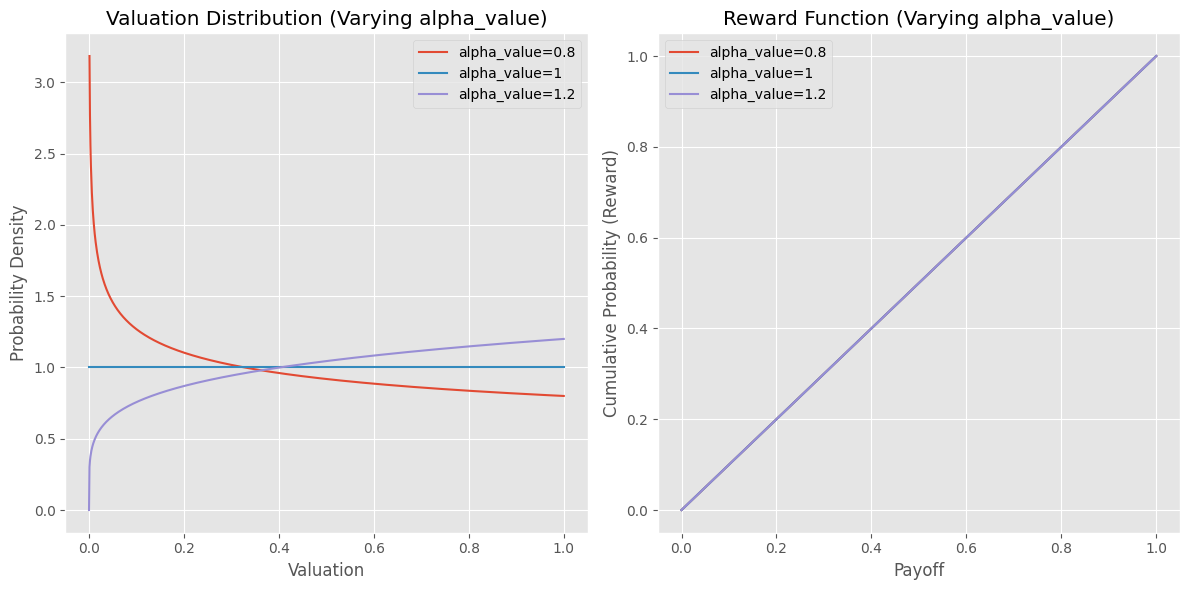

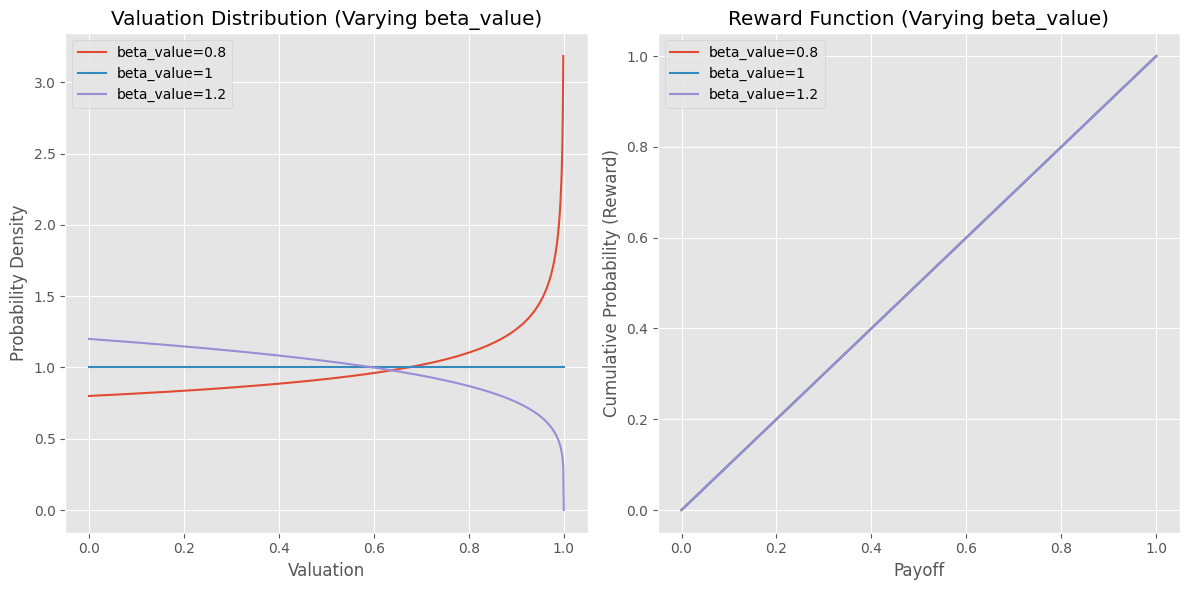

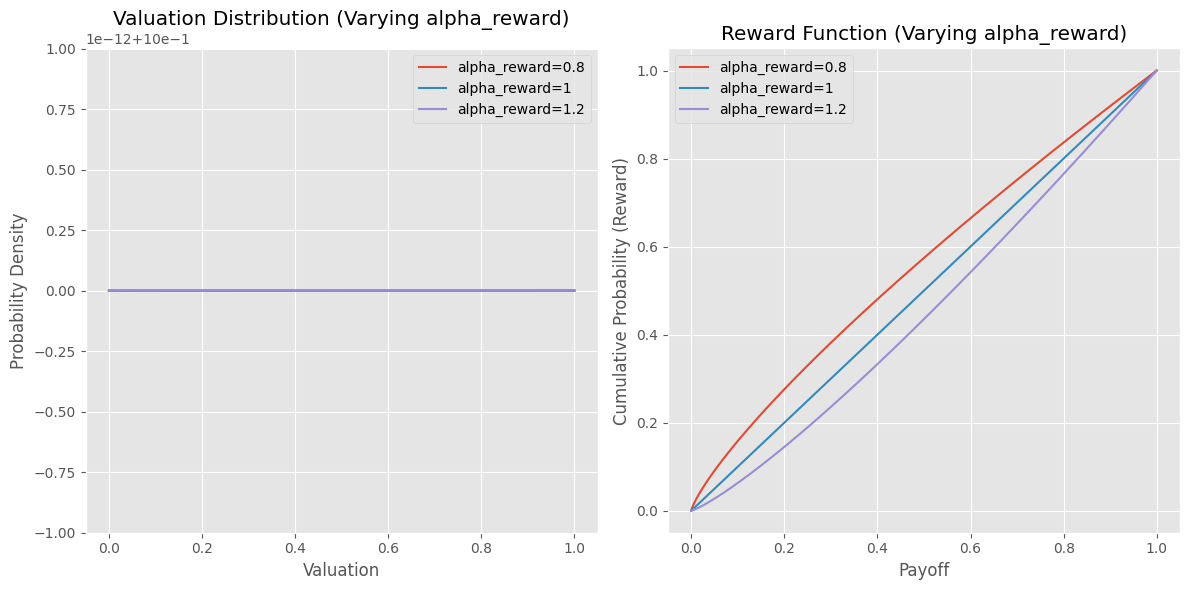

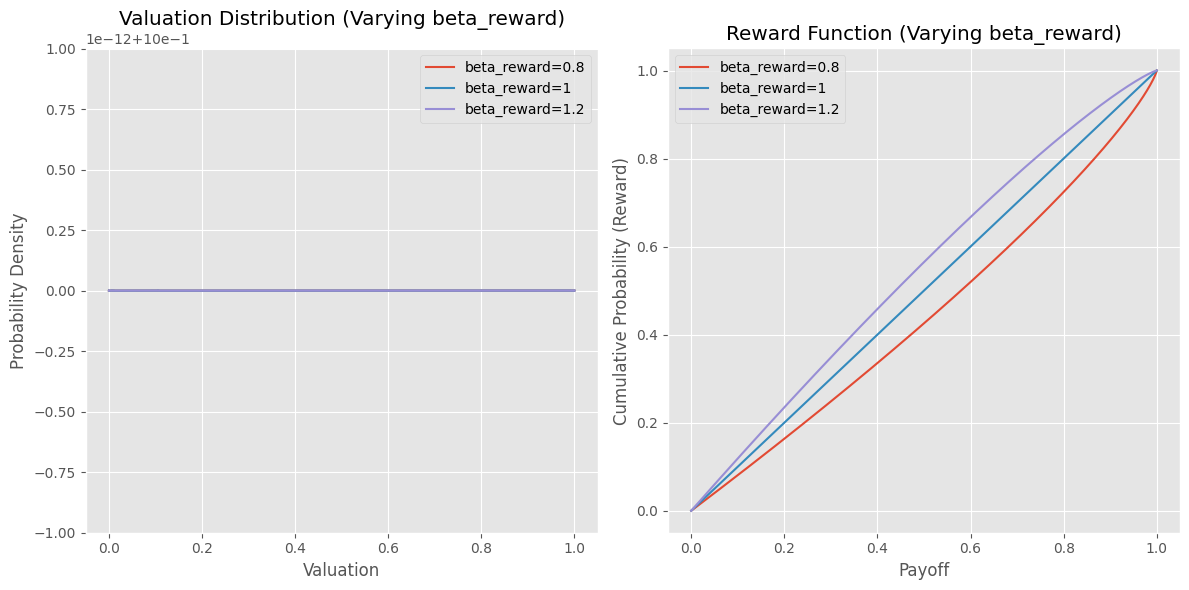

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
plt.style.use('ggplot')

def plot_parameter_effects():
    # Default parameters
    default_alpha_value = 1
    default_beta_value = 1
    default_alpha_reward = 1
    default_beta_reward = 1

    # Parameter values to test around defaults
    parameter_values = [0.8, 1, 1.2]

    # Parameters to vary
    parameters = ['alpha_value', 'beta_value', 'alpha_reward', 'beta_reward']

    x = np.linspace(0, 1, 1000)

    for param in parameters:
        plt.figure(figsize=(12, 6))

        # Store the default parameters
        alpha_value = default_alpha_value
        beta_value = default_beta_value
        alpha_reward = default_alpha_reward
        beta_reward = default_beta_reward

        for value in parameter_values:
            # Update the parameter being varied
            if param == 'alpha_value':
                alpha_value = value
            elif param == 'beta_value':
                beta_value = value
            elif param == 'alpha_reward':
                alpha_reward = value
            elif param == 'beta_reward':
                beta_reward = value

            # Valuation Distribution PDF
            valuation_pdf = beta.pdf(x, alpha_value, beta_value)

            # Reward Function CDF
            reward_cdf = beta.cdf(x, alpha_reward, beta_reward)

            # Plot Valuation Distribution PDF
            plt.subplot(1, 2, 1)
            plt.plot(x, valuation_pdf, label=f'{param}={value}')
            plt.xlabel('Valuation')
            plt.ylabel('Probability Density')
            plt.title(f'Valuation Distribution (Varying {param})')
            plt.grid(True)

            # Plot Reward Function CDF
            plt.subplot(1, 2, 2)
            plt.plot(x, reward_cdf, label=f'{param}={value}')
            plt.xlabel('Payoff')
            plt.ylabel('Cumulative Probability (Reward)')
            plt.title(f'Reward Function (Varying {param})')
            plt.grid(True)

            # Reset parameters to default for the next iteration
            alpha_value = default_alpha_value
            beta_value = default_beta_value
            alpha_reward = default_alpha_reward
            beta_reward = default_beta_reward

        plt.subplot(1, 2, 1)
        plt.legend()
        plt.subplot(1, 2, 2)
        plt.legend()
        plt.tight_layout()
        plt.show()

# Call the function to plot the parameter effects
plot_parameter_effects()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
plt.style.use('ggplot')

class QLearningAgent:
    def __init__(self, alpha_value=1, beta_value=1, alpha_reward=1, beta_reward=1, action_min=0, action_max=1,
                 granularity=20, epsilon=0.1, alpha=0.1, min_val=0, max_val=1, epsilon_decay=None):
        self.actions = np.linspace(action_min, action_max, granularity)
        self.epsilon = epsilon
        self.epsilon_initial = epsilon
        self.epsilon_decay = epsilon_decay
        self.alpha = alpha
        self.min_val = min_val
        self.max_val = max_val
        self.granularity = granularity
        self.q_values = np.zeros((granularity, len(self.actions)))
        self.action_counts = np.zeros((granularity, len(self.actions)))
        self.reward_history = []
        self.alpha_value = alpha_value
        self.beta_value = beta_value
        self.alpha_reward = alpha_reward
        self.beta_reward = beta_reward
        self.valuation_distribution = lambda: np.random.beta(self.alpha_value, self.beta_value)
        self.valuation = self.valuation_distribution()
        self.state = self.get_state(self.valuation)

    def get_state(self, valuation):
        bin_centers = np.linspace(self.min_val, self.max_val, self.granularity)
        return np.argmin(np.abs(bin_centers - valuation))
    
    def refresh_valuation(self):
        self.valuation = self.valuation_distribution()
        self.state = self.get_state(self.valuation)
    
    def choose_action(self):
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.actions)
        else:
            return self.actions[np.argmax(self.q_values[self.state])]
    
    def update_q_values(self, chosen_action, reward):
        action_index = np.where(self.actions == chosen_action)[0][0]
        self.action_counts[self.state, action_index] += 1
        self.q_values[self.state, action_index] += self.alpha * (reward - self.q_values[self.state, action_index])
    
    def feedback(self, payoff, action):
        payoff = np.clip(payoff, 0, 1)
        reward = beta.cdf(payoff, self.alpha_reward, self.beta_reward)
        self.reward_history.append(reward)
        self.update_q_values(action, reward)
        if self.epsilon_decay:
            self.epsilon = max(0.05, self.epsilon_initial * self.epsilon_decay)

class SingleSidedAuction:
    def __init__(self, agents, price_floor=0, price_ceiling=1, payment_rule=None):
        self.agents = agents
        self.price_floor = price_floor
        self.price_ceiling = price_ceiling
        self.payment_rule = payment_rule
        self.profit_history = []
    
    def run_auction(self):
        for agent in self.agents:
            agent.refresh_valuation()
        bids = [max(self.price_floor, min(agent.choose_action(), self.price_ceiling)) for agent in self.agents]
        winner_index, payment = self.payment_rule(bids)
        for idx, agent in enumerate(self.agents):
            if idx == winner_index:
                payoff = agent.valuation - payment
            else:
                payoff = 0
            agent.feedback(payoff, bids[idx])
        self.profit_history.append(payment)
        return {"winner": winner_index, "payment": payment, "bids": bids}

def run_monte_carlo_simulation(agents, auction, num_simulations=10, num_rounds=10000):
    all_bids_for_valuations = [[] for _ in range(len(agents))]
    for sim in range(num_simulations):
        for _ in range(num_rounds):
            auction.run_auction()
        for i, agent in enumerate(agents):
            avg_bids_for_valuation = [agent.actions[np.argmax(agent.q_values[state])] for state in range(agent.granularity)]
            all_bids_for_valuations[i].append(avg_bids_for_valuation)
    
    percentiles = {}
    for i in range(len(agents)):
        avg_bids_for_agent = np.array(all_bids_for_valuations[i])
        percentiles[i] = {
            "5th": np.percentile(avg_bids_for_agent, 5, axis=0),
            "median": np.median(avg_bids_for_agent, axis=0),
            "95th": np.percentile(avg_bids_for_agent, 95, axis=0),
        }
    return percentiles

def plot_monte_carlo_results(agents, percentiles, optimal_bid_rule=None, figsize=(10, 10), title=None):
    valuations = np.linspace(0, 1, agents[0].granularity)
    plt.figure(figsize=figsize)
    
    for i, agent in enumerate(agents):
        plt.fill_between(valuations, percentiles[i]["5th"], percentiles[i]["95th"], color='lightgray', alpha=0.5)
        plt.plot(valuations, percentiles[i]["median"], label=f'Agent {i+1} Median Bid', color='blue')
    
        if optimal_bid_rule:
            optimal_bids = optimal_bid_rule(valuations)
            plt.plot(valuations, optimal_bids, label='Optimal Bid', color='green', linestyle='--')
    
    plt.xlabel('Valuation')
    plt.ylabel('Bid')
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

def first_price_rule(bids):
    highest_bid = np.max(bids)
    potential_winners = np.where(bids == highest_bid)[0]
    winner = np.random.choice(potential_winners) if len(potential_winners) > 1 else potential_winners[0]
    payment = bids[winner]
    return winner, payment

def optimal_bidding_rule(valuations, num_agents=2):
    return (num_agents - 1) / num_agents * valuations

# Function to iterate over all combinations of the parameter grid and run the auction simulation
def run_simulation_for_parameter_grid():
    parameter_values = [0.8, 1, 1.2]
    
    for alpha_value in parameter_values:
        for beta_value in parameter_values:
            for alpha_reward in parameter_values:
                for beta_reward in parameter_values:
                    agents = [QLearningAgent(alpha_value=alpha_value, beta_value=beta_value,
                                             alpha_reward=alpha_reward, beta_reward=beta_reward) for _ in range(2)]
                    auction = SingleSidedAuction(agents, payment_rule=first_price_rule)
                    percentiles = run_monte_carlo_simulation(agents, auction, num_simulations=1, num_rounds=10000)
                    plot_monte_carlo_results(agents, percentiles, optimal_bid_rule=optimal_bidding_rule,
                                             title=f'Alpha_val={alpha_value}, Beta_val={beta_value}, Alpha_rew={alpha_reward}, Beta_rew={beta_reward}')

# Call the function to run the simulations over the parameter grid
run_simulation_for_parameter_grid()